# LIMPIEZA Y PREPROCESAMIENTO DE IMÁGENES
---

### Clasificación de galaxias según su morfología

#### Integrantes
- `Garibay Zepeda, Julio Andrés` (`julio.garibay@iteso.mx`)
- `Crespo Neri, Diego Ubaldo` (`ubaldo.crespo@iteso.mx`)
- `Vázquez Sandoval, Isaac Ernesto` (`isaac.vazquez@iteso.mx`)

---

### Bibliotecas

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops

In [2]:
# Swag
style = "/home/toutl/code/.machine.mplstyle"
if os.path.exists(style):
    plt.style.use(style)

---

### Funciones:

In [3]:
data_folder = Path("../../data/classification/")
original_folder = data_folder / "original"
processed_folder = data_folder / "processed"

In [4]:
def load_image(filename, images_foder="images_gz2"):
    return io.imread(original_folder / images_foder / filename)


def convert_to_single_band(image, to_eye=False):
    if to_eye:
        return rgb2gray(image)

    return image.mean(axis=2)


def extract_object_mask(image, threshold_strength=1):
    gray_image = convert_to_single_band(image)
    threshold = threshold_otsu(gray_image)
    mask = gray_image > (threshold * threshold_strength)
    return mask


def apply_object_mask(image, mask):
    masked = image * mask[..., np.newaxis]
    return masked


def crop_to_object(image, mask, scale=1.5):
    labeled = label(mask)
    regions = regionprops(labeled)

    row_min, col_min, row_max, col_max = max(regions, key=lambda r: r.area).bbox

    cy = (row_min + row_max) // 2
    cx = (col_min + col_max) // 2
    side = int(np.ceil(max(row_max - row_min, col_max - col_min) * scale))
    half = side // 2

    r0, r1 = max(cy - half, 0), min(cy - half + side, image.shape[0])
    c0, c1 = max(cx - half, 0), min(cx - half + side, image.shape[1])

    return image[r0:r1, c0:c1]


def resize_image(image, size=(64, 64)):
    return cv2.resize(image, size)


def normalize_intensity(image):
    return np.array(image / 255).astype("float16")

---

### **Ejemplo:**

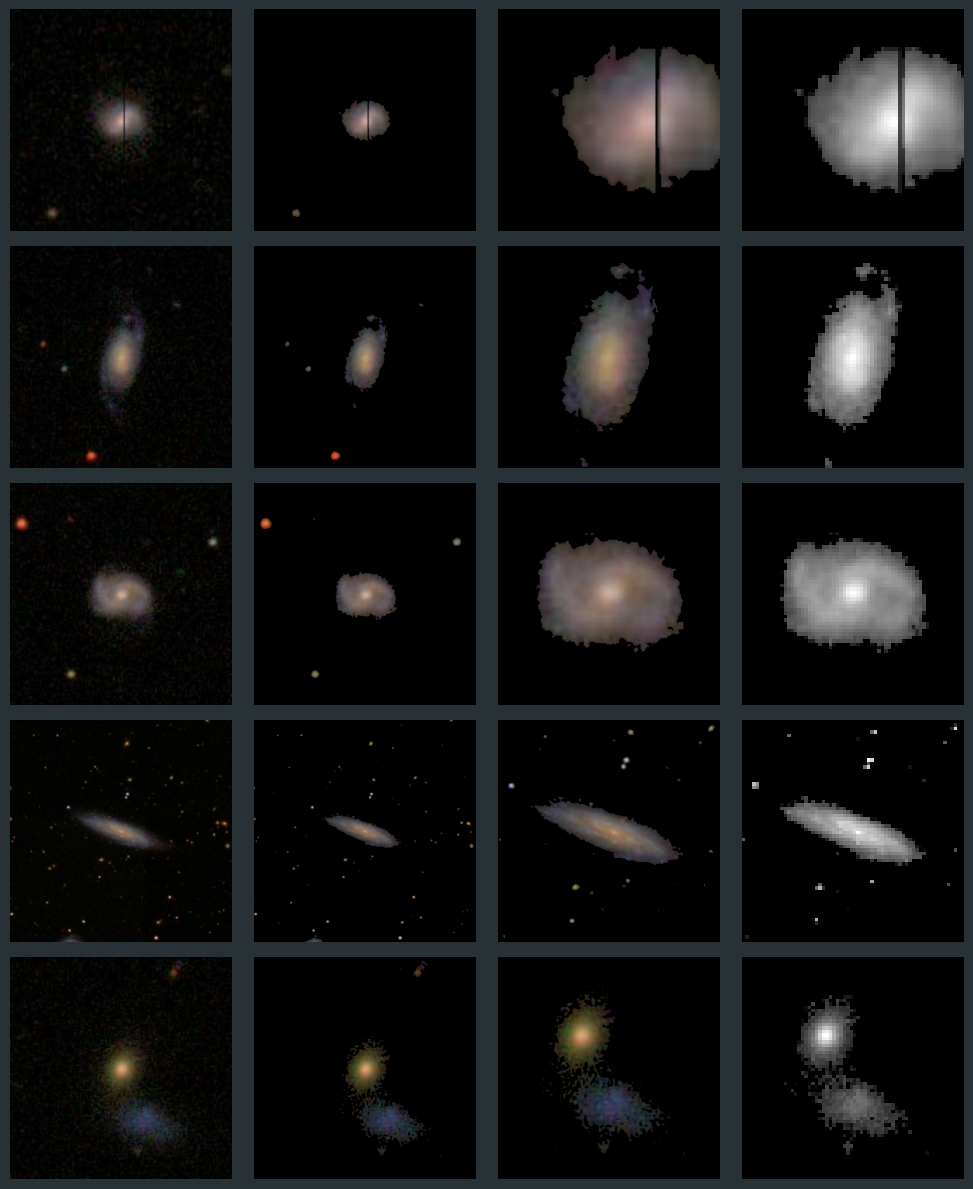

In [5]:
test_images = ["93.jpg", "85.jpg", "35.jpg", "42.jpg", "7.jpg"]

fig, axes = plt.subplots(5, 4, figsize=(10, 12), tight_layout=True)

for i, img_name in enumerate(test_images):
    img = load_image(img_name)
    mask = extract_object_mask(img)
    masked = apply_object_mask(img, mask)
    cropped = crop_to_object(masked, mask)
    resized = resize_image(cropped)
    band = convert_to_single_band(resized)
    final = normalize_intensity(band)
    
    axes[i, 0].imshow(img)
    axes[i, 1].imshow(masked)
    axes[i, 2].imshow(cropped)
    axes[i, 3].imshow(band, cmap="gray")

    for ax in axes[i]:
        ax.axis("off")
plt.show()

Canal de limpieza y preprocesamiento:

- Aplicamos una máscara para mantener únicamente los objetos cósmicos.
- Como todas las imágnes están centradas mantenemos el objeto obtenido en la máscara al centro.
- De esta manera obtenemos la mejor calidad disponible de el objeto de interés.
- Como se puede observar, en cada paso se está manteniendo solo el objeto central.
- Hasta que nuestra imagen sea casi por completo la galaxia.

---

### Aplicar canal a la colección

In [6]:
images_metadata_df = pd.read_csv(processed_folder / "galaxy_morphology.csv")
display(images_metadata_df.head())

,image_id,class
0,3,S
1,4,S
2,6,S
3,7,S
4,13,E


Se decidió eliminar la clase de Artefactos y objetos no especificados (`A`) por su reducida proporción en el conjunto de datos.

Además, por la gran cantidad de datos se tomará una muestra proporcional de los mismos.

In [7]:
cleaned_metadata = images_metadata_df.loc[
    images_metadata_df["class"].isin(["S", "E"])
].assign(**{"class": lambda df: df["class"].map({"S": 0, "E": 1})})

display(cleaned_metadata)

,image_id,class
0,3,0
1,4,0
2,6,0
3,7,0
4,13,1
...,...,...
70618,295289,0
70619,295290,1
70620,295291,0
70621,295294,0


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
sample_metadata, _ = train_test_split(
    cleaned_metadata,
    test_size=0.85,
    stratify=cleaned_metadata["class"],
    random_state=35,
)
display(sample_metadata)

,image_id,class
44034,110581,0
18536,53890,0
68007,268229,0
26851,69751,0
70472,294591,0
...,...,...
2789,8148,1
57739,199856,1
62761,232492,1
49617,144830,0


In [10]:
filenames = sample_metadata["image_id"].astype(str).add(".jpg").values

display(filenames[:10])

array(['110581.jpg', '53890.jpg', '268229.jpg', '69751.jpg', '294591.jpg',
       '287069.jpg', '58579.jpg', '49874.jpg', '17922.jpg', '7030.jpg'],
      dtype=object)

In [11]:
def apply_pipeline_to_all(filenames):
    processed_images = []
    n_images = len(filenames)
    next_mark = 10

    for i, img_name in enumerate(filenames):
        progress = i * 100 / n_images

        if progress >= next_mark:
            print(f"Progress: {next_mark}%")
            next_mark += 10

        img = load_image(img_name)
        mask = extract_object_mask(img)
        masked = apply_object_mask(img, mask)
        cropped = crop_to_object(masked, mask)
        resized = resize_image(cropped)
        band = convert_to_single_band(resized)
        final = normalize_intensity(band)
        if final.max() > 1:
            raise Exception(f"wot?: {final.max()}")
        processed_images.append(final)

    return processed_images

In [12]:
processed_images = apply_pipeline_to_all(filenames)

Progress: 10%
Progress: 20%
Progress: 30%
Progress: 40%
Progress: 50%
Progress: 60%
Progress: 70%
Progress: 80%
Progress: 90%


In [13]:
to_save_filename = f"sample_64x64_{len(sample_metadata)}"

sample_metadata.to_csv(processed_folder / f"{to_save_filename}.csv", index=False)

In [14]:
# Guardamos los arreglos procesados en un archivo de matrices de numpy
np.savez(
    processed_folder / f"{to_save_filename}.npz",
    **{
        filename: arr
        for filename, arr in zip(
            sample_metadata["image_id"].astype(str), processed_images
        )
    },
)

Array names:  ['110581', '53890', '268229', '69751', '294591', '287069', '58579', '49874', '17922', '7030']


'File name:'

'110581'

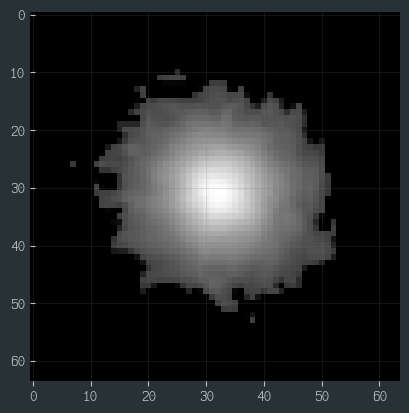

In [15]:
# Ejemplo de lectura de imágenes
arrays_file = np.load(processed_folder / f"{to_save_filename}.npz")

print("Array names: ", arrays_file.files[:10])

file = sample_metadata["image_id"].astype(str).reset_index().loc[0]["image_id"]
display("File name:", file)
plt.imshow(arrays_file[file], cmap="grey")
plt.show()

---

#### 4. Conclusiones

Para poder lograr construir un buen modelo de clasificación de imágenes de galaxias, tendremos en cuenta lo siguiente:
- Hay que encapsular los objetos de interés para evitar que el el modelo utilizado se sobreajuste al ruido o tenga sesgo por la aparición de otros objetos en sus vecinidades.
    - También para que haya una mayor importancia de la intensidad de la galaxia, en lugar del fondo
- Las imagenes astronómicas requieren de un tratamiento especial, diferente a las imágenes comunes. No todos los filtros funcionan con estas.
- Tenemos que prestar atención en cómo representa el modelo la proporción de categorías en la variable objetivo.

Modelo a aplicar:

En base a lo observado y al estado del arte en análisis de imágenes, lo más conveniente podría ser una Red Neuronal Convolucional. Ya que...
- Son robustas frente a datos complejos.
    - Patrones raros.
- No necesitamos interpretabilidad en el modelo.
- Generalizan bien, en lugar de elegir pixel por pixel aprenden estructuras generales.

También podríamos probar una máquina de soporte vectorial con PCA, para probar un modelo más ligero.
- Sin embargo, habría que hacer otras transformaciones para poderlos utilizar bien.

---

#### 5. Datos

Links de descarga:

[Images (Zenodo)](https://zenodo.org/records/3565489/files/images_gz2.zip?download=1)

[Classification Table (GalaxyZoo)](https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz)